# Latent Space Analysis Notebook (BetaVAE)

## 1. Setup and Imports

In [1]:
import yaml
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.manifold import TSNE
from torchvision.utils import save_image
import umap
import os
from vae_models import *
from experiment import VAEXperiment
from dataset import VAEDataset

%matplotlib inline

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuration

In [2]:
# === Parameters to set ===
CONFIG_PATH = 'configs/afhq_experiments/betavae_afhq.yaml'
CHECKPOINT_PATH = 'logs/BetaVAE/version_10/checkpoints/last.ckpt'
EXP_NAME = 'betavae_afhq_v10' # A name for the output file
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
LIMIT_BATCHES = -1 # Number of batches to process for speed. -1 for all batches.
TSNE_PERPLEXITY = 30
# ==========================

# Load config file
with open(CONFIG_PATH, 'r') as file:
    config = yaml.safe_load(file)

# For reproducibility
torch.manual_seed(config['exp_params']['manual_seed'])
np.random.seed(config['exp_params']['manual_seed'])

print(f"Device: {DEVICE}")
print(f"Config loaded from: {CONFIG_PATH}")
print(f"Checkpoint: {CHECKPOINT_PATH}")

Device: cuda
Config loaded from: configs/afhq_experiments/betavae_afhq.yaml
Checkpoint: logs/BetaVAE/version_10/checkpoints/last.ckpt


## 3. Load Model and Data

In [3]:
# Load model from checkpoint
model = vae_models[config['model_params']['name']](**config['model_params'])
experiment = VAEXperiment(model, config['exp_params'])

print("Loading checkpoint...")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
experiment.load_state_dict(checkpoint['state_dict'])

model = experiment.model
model.eval()
model.to(DEVICE)

# Load the validation dataset
data = VAEDataset(**config["data_params"])
data.setup()
val_dataloader = data.val_dataloader()

model_name = config['model_params']['name']
print(f"Successfully loaded model: {model_name}")
print(f"Validation dataset size: {len(val_dataloader.dataset)}")

/opt/conda/lib/python3.10/site-packages/pytorch_lightning/core/lightning.py:2054: DeprecationWarning: `torch.distributed._sharded_tensor` will be deprecated, use `torch.distributed._shard.sharded_tensor` instead
  from torch.distributed._sharded_tensor import pre_load_state_dict_hook, state_dict_hook


Loading checkpoint...
Successfully loaded model: BetaVAE
Validation dataset size: 1000


## 4. Extract Latent Vectors

In [4]:
latent_vectors = []
labels = []

with torch.no_grad():
    for i, batch in enumerate(val_dataloader):
        input, label = batch
        input = input.to(DEVICE)
        
        model_name = config['model_params']['name']
        if model_name == 'ConditionalVAE':
            outputs = model.forward(input, labels=label.to(DEVICE))
        else:
            outputs = model.forward(input)

        if model_name in ['VanillaVAE', 'BetaVAE', 'ConditionalVAE']:
            mu, log_var = outputs[2], outputs[3]
        else:
            mu, log_var = model.encode(input)
            
        z = model.reparameterize(mu, log_var)
        
        latent_vectors.append(z.cpu().numpy())
        labels.append(label.cpu().numpy())
        
        if i % 10 == 0:
            print(f"Processed batch {i+1}/{len(val_dataloader)}")
            
        if LIMIT_BATCHES > 0 and i >= LIMIT_BATCHES - 1:
            print(f"Processed {i+1} batches (limit reached).")
            break

latent_vectors = np.concatenate(latent_vectors, axis=0)
labels = np.concatenate(labels, axis=0)

print(f"Extracted {len(latent_vectors)} latent vectors of dimension {latent_vectors.shape[1]}.")

Processed batch 1/16
Processed batch 11/16
Extracted 1000 latent vectors of dimension 128.


## 5. Visualize with t-SNE

Performing t-SNE... (This may take a while)
Plotting results...
Plot saved to results_analysis/BetaVAE_betavae_afhq_v10/tsne_BetaVAE_betavae_afhq_v10.png


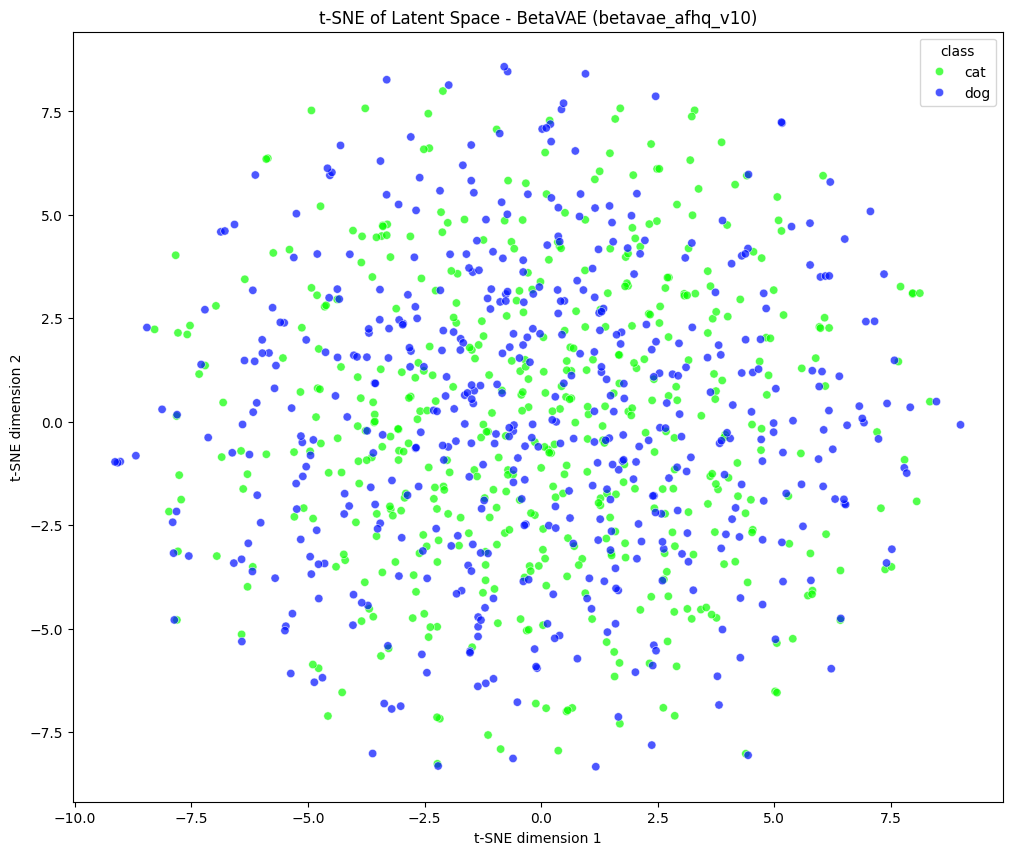

In [5]:
print("Performing t-SNE... (This may take a while)")
tsne = TSNE(n_components=2, 
            random_state=config['exp_params']['manual_seed'], 
            perplexity=min(TSNE_PERPLEXITY, len(latent_vectors) - 1),
            max_iter=1000,
            n_jobs=-1)
tsne_results = tsne.fit_transform(latent_vectors)

df = pd.DataFrame(tsne_results, columns=['tsne1', 'tsne2'])
df['label'] = labels

try:
    class_names = val_dataloader.dataset.classes
    df['class'] = [class_names[int(l)] for l in labels]
except Exception as e:
    print(f"Could not get class names, using numeric labels. Error: {e}")
    df['class'] = df['label']

print("Plotting results...")
plt.figure(figsize=(12, 10))

sns.scatterplot(
    x='tsne1', y='tsne2',
    hue='class',
    palette=sns.color_palette("hsv", len(df['class'].unique())), 
    data=df,
    legend="full",
    alpha=0.7
)

plt.title(f"t-SNE of Latent Space - {model_name} ({EXP_NAME})")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")

output_filename = f"results_analysis/{model_name}_{EXP_NAME}/tsne_{model_name}_{EXP_NAME}.png"
os.makedirs(os.path.dirname(output_filename), exist_ok=True)
plt.savefig(output_filename)
print(f"Plot saved to {output_filename}")

plt.show()

## 5-b. UMAP

Performing UMAP... (This may take a while)


/opt/conda/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Plotting results...
Plot saved to results_analysis/BetaVAE_betavae_afhq_v10/umap_BetaVAE_betavae_afhq_v10.png


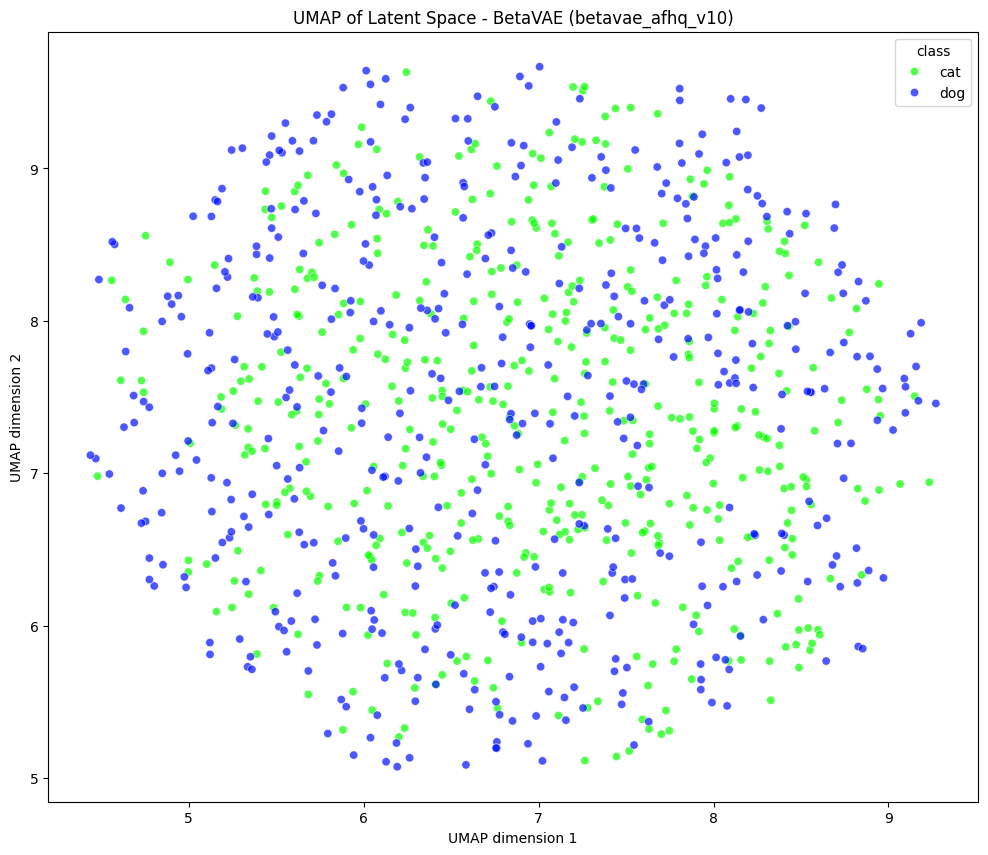

In [6]:
print("Performing UMAP... (This may take a while)")
reducer = umap.UMAP(random_state=config['exp_params']['manual_seed'])
embedding = reducer.fit_transform(latent_vectors)

df_umap = pd.DataFrame(embedding, columns=['umap1', 'umap2'])
df_umap['label'] = labels
df_umap['class'] = df['class']

print("Plotting results...")
plt.figure(figsize=(12, 10))

sns.scatterplot(
    x='umap1', y='umap2',
    hue='class',
    palette=sns.color_palette("hsv", len(df_umap['class'].unique())), 
    data=df_umap,
    legend="full",
    alpha=0.7
)

plt.title(f"UMAP of Latent Space - {model_name} ({EXP_NAME})")
plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")

output_filename_umap = f"results_analysis/{model_name}_{EXP_NAME}/umap_{model_name}_{EXP_NAME}.png"
os.makedirs(os.path.dirname(output_filename_umap), exist_ok=True)
plt.savefig(output_filename_umap)
print(f"Plot saved to {output_filename_umap}")

plt.show()

## 5-c. Quantitative Analysis: Classifier on Latent Space

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("Performing quantitative analysis with a classifier...")

X_train, X_test, y_train, y_test = train_test_split(
    latent_vectors,
    labels,
    test_size=0.2,
    random_state=config['exp_params']['manual_seed']
)
classifier = LogisticRegression(random_state=config['exp_params']['manual_seed'], max_iter=1000)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Classifier Accuracy: {accuracy * 100:.2f}%")

Performing quantitative analysis with a classifier...
Classifier Accuracy: 76.00%


## 5-d. PCA

Performing PCA...
Plotting results...
Plot saved to results_analysis/BetaVAE_betavae_afhq_v10/pca_BetaVAE_betavae_afhq_v10.png


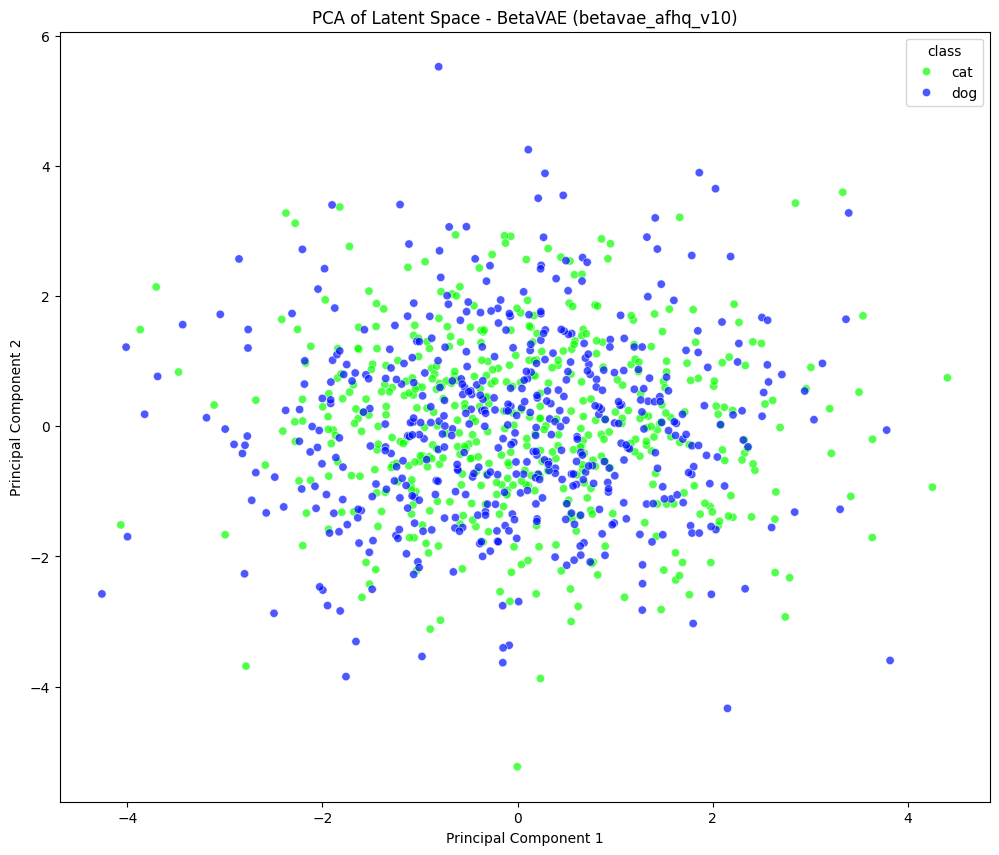

In [8]:
from sklearn.decomposition import PCA

print("Performing PCA...")

pca = PCA(n_components=2)
pca_results = pca.fit_transform(latent_vectors)

df_pca = pd.DataFrame(pca_results, columns=['pca1', 'pca2'])
df_pca['label'] = labels
df_pca['class'] = df['class']
print("Plotting results...")
plt.figure(figsize=(12, 10))

sns.scatterplot(
    x='pca1', y='pca2',
    hue='class',
    palette=sns.color_palette("hsv", len(df_pca['class'].unique())), 
    data=df_pca,
    legend="full",
    alpha=0.7
)

plt.title(f"PCA of Latent Space - {model_name} ({EXP_NAME})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

output_filename_pca = f"results_analysis/{model_name}_{EXP_NAME}/pca_{model_name}_{EXP_NAME}.png"
plt.savefig(output_filename_pca)
print(f"Plot saved to {output_filename_pca}")

plt.show()

## 5-e. LDA

Performing LDA (n_components=1) for visualization...
Plotting LDA results (as density plot)...
LDA plot saved to results_analysis/BetaVAE_betavae_afhq_v10/lda_BetaVAE_betavae_afhq_v10.png


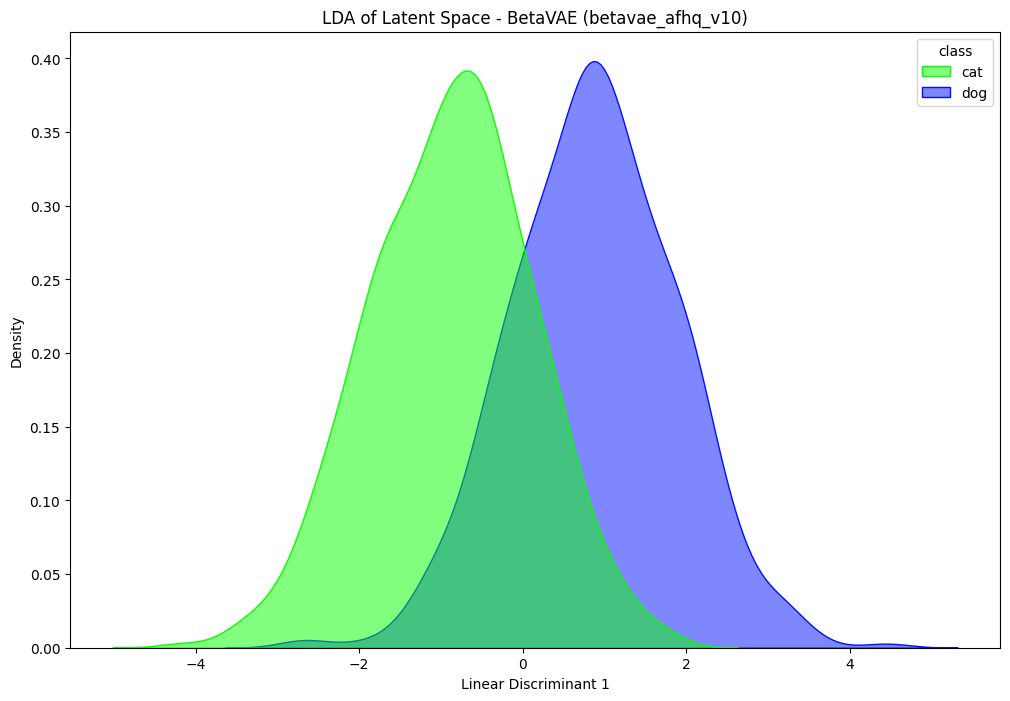

In [9]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

print("Performing LDA (n_components=1) for visualization...")

lda = LinearDiscriminantAnalysis(n_components=1)
lda_results = lda.fit_transform(latent_vectors, labels)

df_lda = pd.DataFrame()
df_lda['LDA Component 1'] = lda_results[:, 0]
df_lda['y_axis'] = 0
df_lda['label'] = labels
df_lda['class'] = ['dog' if l == 1 else 'cat' for l in labels]

print("Plotting LDA results (as density plot)...")
plt.figure(figsize=(12, 8))

sns.kdeplot(
    data=df_lda,
    x='LDA Component 1',
    hue='class',
    palette=sns.color_palette("hsv", 2),
    fill=True,
    common_norm=False,
    alpha=0.5
)

plt.title(f"LDA of Latent Space - {model_name} ({EXP_NAME})")
plt.xlabel("Linear Discriminant 1")
plt.ylabel("Density")

output_filename_lda = f"results_analysis/{model_name}_{EXP_NAME}/lda_{model_name}_{EXP_NAME}.png"
plt.savefig(output_filename_lda)
print(f"LDA plot saved to {output_filename_lda}")
plt.show()

## 6. Latent Space Traversal

In [10]:
import os

print("Performing Latent Space Traversal...")

output_dir = f"results_analysis/traversals/{EXP_NAME}"
os.makedirs(output_dir, exist_ok=True)
print(f"Saving results to: {output_dir}")

mean_latent_vector = torch.from_numpy(latent_vectors.mean(axis=0, keepdims=True)).to(DEVICE)

latent_std = latent_vectors.std(axis=0)
dims_to_traverse = np.argsort(latent_std)[-10:]

traversal_range = torch.linspace(-5, 5, 11)

for dim in dims_to_traverse:
    print(f"Traversing dimension: {dim}")

    traversal_vectors = mean_latent_vector.repeat(len(traversal_range), 1)

    for i, val in enumerate(traversal_range):
        traversal_vectors[i, dim] = val

    with torch.no_grad():
        generated_images = model.decode(traversal_vectors)

    output_filename = f"{output_dir}/traversal_dim_{dim}.png"
    save_image(generated_images.data,
               output_filename,
               nrow=len(traversal_range),
               normalize=True)

    print(f"Saved traversal grid to {output_filename}")

print("Latent Space Traversal complete.")

Performing Latent Space Traversal...
Saving results to: results_analysis/traversals/betavae_afhq_v10
Traversing dimension: 50
Saved traversal grid to results_analysis/traversals/betavae_afhq_v10/traversal_dim_50.png
Traversing dimension: 24
Saved traversal grid to results_analysis/traversals/betavae_afhq_v10/traversal_dim_24.png
Traversing dimension: 109
Saved traversal grid to results_analysis/traversals/betavae_afhq_v10/traversal_dim_109.png
Traversing dimension: 22
Saved traversal grid to results_analysis/traversals/betavae_afhq_v10/traversal_dim_22.png
Traversing dimension: 19
Saved traversal grid to results_analysis/traversals/betavae_afhq_v10/traversal_dim_19.png
Traversing dimension: 48
Saved traversal grid to results_analysis/traversals/betavae_afhq_v10/traversal_dim_48.png
Traversing dimension: 60
Saved traversal grid to results_analysis/traversals/betavae_afhq_v10/traversal_dim_60.png
Traversing dimension: 0
Saved traversal grid to results_analysis/traversals/betavae_afhq_v10